In [1]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import f1_score, accuracy_score, classification_report
import tensorflow as tf

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import keras
# pour manipuler le fichier
from pathlib import Path
import ipynbname
import re


I0000 00:00:1785582662.636037 1112031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785582662.804682 1112031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785582664.380164 1112031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:


# %%
val_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split_3classes/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='grayscale'
)



# %%
test_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split_3classes/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42,
    shuffle=False,
    color_mode='grayscale'
)



Found 2083 files belonging to 3 classes.
Found 2084 files belonging to 3 classes.


W0000 00:00:1785582666.290841 1112031 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
@keras.saving.register_keras_serializable()
class SparseF1Score(tf.keras.metrics.F1Score):
    """F1Score de Keras adaptée aux labels sparses (entiers) plutôt que one-hot."""
    def __init__(self, num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes_ = num_classes

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=self.num_classes_)
        return super().update_state(y_true, y_pred, sample_weight)
    


In [4]:
ipynb_name = ipynbname.name()  # "plot_model_xxxxxx"
match = re.search(r"plot_model_(.+)", ipynb_name)
model_name = match.group(1)
print(model_name)
model_file= model_name + ".keras"
model_loaded = load_model(model_file)
model_loaded.summary()

cnn_512_3classes


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 299, 299, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 299, 299, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer1 (Conv2D)            │ (None, 299, 299, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization1             │ (None, 299, 299, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer1              │ (None, 149, 149, 32)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer2 (Conv2D)            │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization2             │ (None, 149, 149, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer2              │ (None, 74, 74, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer3 (Conv2D)            │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization3             │ (None, 74, 74, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer3              │ (None, 37, 37, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer4 (Conv2D)            │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization4             │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer4              │ (None, 18, 18, 256)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer5 (Conv2D)            │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization5             │ (None, 18, 18, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer5              │ (None, 9, 9, 512)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,910,478 (18.73 MB)

 Trainable params: 1,636,164 (6.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

 Optimizer params: 3,272,330 (12.48 MB)

In [ ]:

# jeu de test
test_pred = model_loaded.predict(test_ds)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)

# sauvegarde sous la forme npy 
y_true_test_model_name="y_true_test_"+model_name+".npy"
y_prob_test__model_name="y_prob_test_"+model_name+".npy"
np.save(y_true_test_model_name, y_true_test_class)  # changer le nom selon le modèle
np.save(y_prob_test__model_name, test_pred)


I0000 00:00:1785582666.875724 1112213 service.cc:153] XLA service 0x7f9084039b80 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785582666.875748 1112213 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1785582666.884341 1112213 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785582667.018435 1112213 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 274ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 276ms/step


              precision    recall  f1-score   support

           0       0.89      0.80      0.84       337
           1       0.92      0.96      0.94      1014
           2       0.91      0.91      0.91       733

    accuracy                           0.92      2084
   macro avg       0.91      0.89      0.90      2084
weighted avg       0.91      0.92      0.91      2084



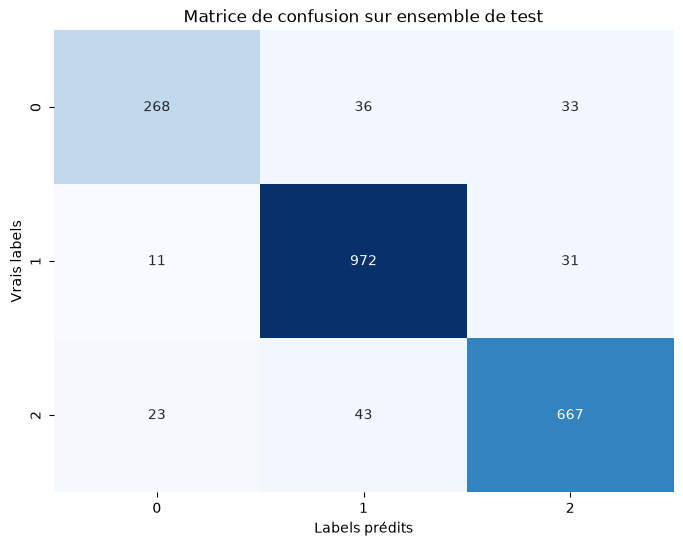

In [6]:
# Pour avoir le nom des classes (des poissons)
class_names = test_ds.class_names

print(metrics.classification_report(y_true_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


              precision    recall  f1-score   support

           0       0.90      0.80      0.85       338
           1       0.93      0.95      0.94      1013
           2       0.90      0.91      0.90       732

    accuracy                           0.91      2083
   macro avg       0.91      0.89      0.90      2083
weighted avg       0.91      0.91      0.91      2083



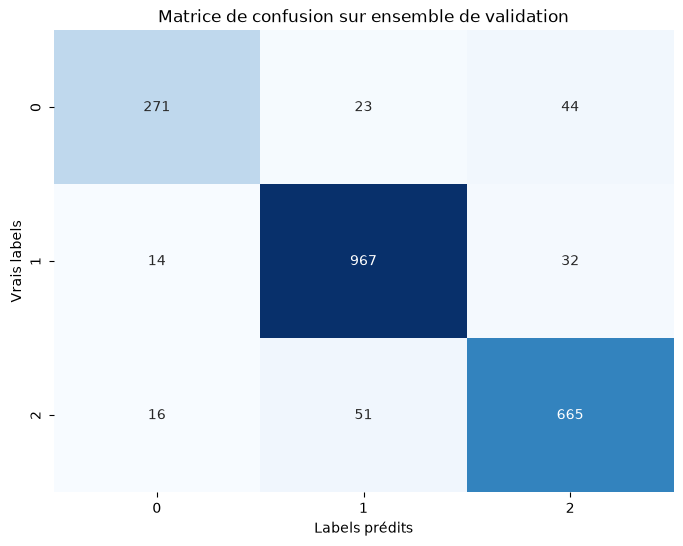

In [7]:
print(metrics.classification_report(y_true_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()
